# TP 2 — Remplissage des valeurs manquantes

**Jour 2 — chapitre 02 : Data cleaning**

## Mise en situation

Sur le dataset Titanic, la colonne « Age » comporte de nombreuses valeurs manquantes. Il
s'agit de définir et d'appliquer une stratégie d'imputation cohérente.

Le premier modèle (notebook 01) a dû laisser `Age` de côté à cause de ces valeurs
manquantes, alors que l'âge fait partie des hypothèses métier formulées au jour 1.

Comme au jour 1, ce notebook charge les données via `seaborn` pour rester autonome. En
formation réelle, utilisez le `train.csv` de la compétition Kaggle *Titanic*.


In [1]:
import pandas as pd
import seaborn as sns

titanic_raw = sns.load_dataset("titanic")
titanic = titanic_raw.rename(columns={
    "survived": "Survived",
    "pclass": "Pclass",
    "sex": "Sex",
    "age": "Age",
    "sibsp": "SibSp",
    "parch": "Parch",
    "fare": "Fare",
    "embarked": "Embarked",
    "who": "Who",
})
titanic = titanic[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]].copy()
titanic.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Étape 1 — Quantifier les valeurs manquantes

**Question de réflexion :** quel pourcentage de valeurs manquantes a-t-on par colonne ?
Ce pourcentage change-t-il la stratégie à adopter (suppression vs imputation) ?


In [2]:
missing = titanic.isnull().sum()
missing_pct = (missing / len(titanic) * 100).round(1)
pd.DataFrame({"valeurs_manquantes": missing, "pourcentage": missing_pct}).sort_values(
    "valeurs_manquantes", ascending=False
)


,valeurs_manquantes,pourcentage
Age,177,19.9
Embarked,2,0.2
Survived,0,0.0
Pclass,0,0.0
Sex,0,0.0
SibSp,0,0.0
Parch,0,0.0
Fare,0,0.0


**Ce qu'on observe** : `Age` a une proportion de valeurs manquantes trop importante pour
être supprimée sans perdre une bonne partie du dataset — il faut imputer. `Embarked` a
très peu de valeurs manquantes (voire aucune ici) : une imputation simple par le mode
suffira largement.


## Étape 2 — Étudier la distribution de l'âge avant imputation

**Question de réflexion :** à quoi ressemble la distribution de l'âge ? Est-elle plutôt
symétrique, ou déformée par des valeurs extrêmes ?


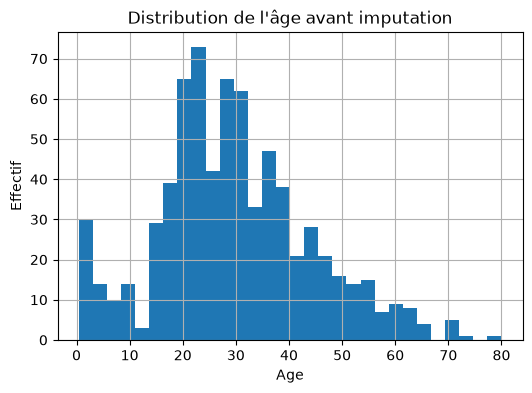

Moyenne : 29.7
Médiane : 28.0


In [3]:
import matplotlib.pyplot as plt

titanic["Age"].hist(bins=30, figsize=(6, 4))
plt.title("Distribution de l'âge avant imputation")
plt.xlabel("Age")
plt.ylabel("Effectif")
plt.show()

print("Moyenne :", round(titanic["Age"].mean(), 1))
print("Médiane :", titanic["Age"].median())


**Ce qu'on observe** : la distribution est légèrement asymétrique (davantage de jeunes
adultes, une longue traîne vers les âges élevés). C'est précisément dans ce cas de figure
que la **médiane** est préférable à la moyenne comme valeur d'imputation : elle est moins
sensible aux valeurs extrêmes.


## Étape 3 — Imputer l'âge par la médiane, calculée par groupe (titre extrait du nom)

**Question de réflexion :** plutôt qu'une médiane unique pour tout le monde, peut-on
trouver un groupe pertinent qui permettrait une imputation plus fine ? (indice : le titre
social contenu dans le nom du passager — Mr, Miss, Mrs — est un bon proxy d'âge, mais le
dataset seaborn ne contient pas la colonne `Name`)


In [4]:
# Le dataset seaborn ne fournit pas la colonne "Name" (contrairement au train.csv Kaggle),
# donc on n'a pas ici de "Title" a extraire. On utilise le meilleur proxy disponible dans
# ce jeu de donnees : le sexe et la classe, qui sont fortement correles a l'age moyen.
#
# Avec le vrai train.csv Kaggle, la demarche recommandee est :
#   titanic["Title"] = titanic["Name"].str.extract(r" ([A-Za-z]+)\.")
#   age_median_par_titre = titanic.groupby("Title")["Age"].transform("median")
#   titanic["Age"] = titanic["Age"].fillna(age_median_par_titre)

age_median_par_groupe = titanic.groupby(["Sex", "Pclass"])["Age"].transform("median")
titanic["Age"] = titanic["Age"].fillna(age_median_par_groupe)

# securite : si un groupe (Sex, Pclass) etait entierement vide en Age, on retombe
# sur la mediane globale
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())

titanic["Age"].isnull().sum()


np.int64(0)

**Ce qu'on observe** : plus aucune valeur manquante sur `Age`. Imputer par groupe (ici
sexe et classe, ou titre social avec le vrai dataset Kaggle) donne une estimation plus
fine qu'une médiane unique appliquée à toute la population.


## Étape 4 — Traiter la variable « Embarked » par le mode

**Question de réflexion :** pour une variable catégorielle avec très peu de valeurs
manquantes, quelle est la stratégie la plus simple et la plus raisonnable ?


In [5]:
mode_embarked = titanic["Embarked"].mode()[0]
print("Valeur la plus fréquente (mode) :", mode_embarked)

titanic["Embarked"] = titanic["Embarked"].fillna(mode_embarked)
titanic["Embarked"].isnull().sum()


Valeur la plus fréquente (mode) : S


np.int64(0)

**Ce qu'on observe** : on remplace les rares valeurs manquantes par la catégorie la plus
fréquente. C'est une stratégie standard et peu risquée quand le nombre de valeurs
manquantes est faible.


## Étape 5 — Comparer la distribution avant/après imputation

**Question de réflexion :** l'imputation a-t-elle dénaturé la distribution originale de
l'âge ?


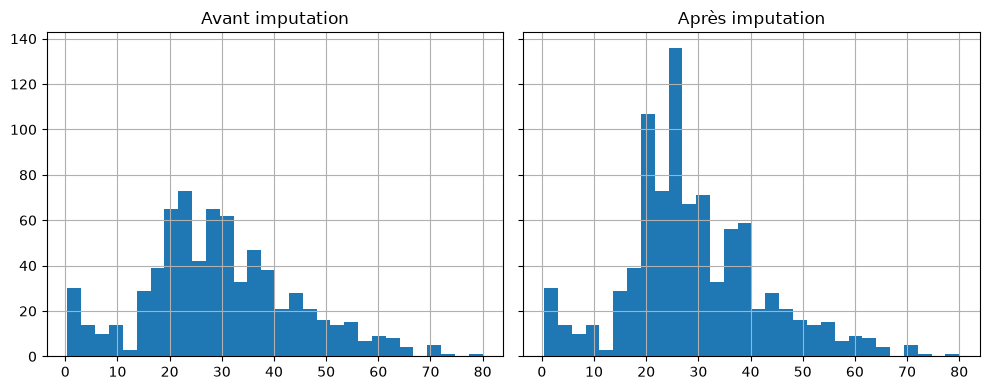

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
titanic_raw["age"].hist(bins=30, ax=axes[0])
axes[0].set_title("Avant imputation")
titanic["Age"].hist(bins=30, ax=axes[1])
axes[1].set_title("Après imputation")
plt.tight_layout()
plt.show()


**Ce qu'on observe** : la forme générale de la distribution est préservée, avec un pic
plus marqué autour des valeurs médianes imputées — c'est l'effet attendu et acceptable
d'une imputation par la médiane. Si ce pic devenait disproportionné, ce serait le signal
qu'il faut revoir la stratégie (par exemple imputer par un modèle prédictif plutôt qu'une
statistique simple).

**À retenir pour le débriefing du TP** : comparez les stratégies utilisées par les
participants (médiane globale vs médiane par groupe) et discutez de l'impact sur le score
final du modèle en fin de journée.
